# Food-101 Proj Demo Notebook



- 使用 `Food-101`
- 只选 `10` 个类别
- 使用 `ResNet18` 迁移学习
- 冻结 backbone
- 替换最后一层
- 比较两个 learning rate
- 输出准确率、损失和 top-3 预测
- 自动整理失败案例与小组项目连接点




## 1. 环境与依赖


```python
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "torch", "torchvision", "numpy", "scikit-learn", "pillow", "matplotlib", "certifi"])
```

这个 notebook 已经内置了 `curl -k` 下载兜底逻辑：

- Food-101 数据集优先检查本地文件，不存在时直接下载压缩包并解压
- ResNet18 预训练权重优先走 torchvision，失败后自动用 `curl -k` 下载到本地缓存


    


In [2]:
import json
import math
import os
import random
import ssl
import subprocess
import tarfile
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from torchvision.datasets import Food101

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.unicode_minus"] = False
    


In [3]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [4]:
DATA_ROOT = Path("data")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

SELECTED_CLASSES = [
    "ramen",
    "sushi",
    "pizza",
    "hamburger",
    "fried_rice",
    "ice_cream",
    "steak",
    "donuts",
    "hot_dog",
    "spaghetti_bolognese",
]

NUM_EPOCHS = 20
BATCH_SIZE = 32
LEARNING_RATES = [1e-3, 1e-4]
DOWNLOAD_DATA = True
USE_PRETRAINED_WEIGHTS = True

FOOD101_URL = "http://data.vision.ee.ethz.ch/cvl/food-101.tar.gz"
RESNET18_WEIGHTS_URL = "https://download.pytorch.org/models/resnet18-f37072fd.pth"

# 为了让 notebook 在 CPU 上也更容易跑通，默认每类只抽一部分样本。
# 如使用 10 个类别的全部样本，下面两个值改成 None。
MAX_TRAIN_PER_CLASS = 300
MAX_TEST_PER_CLASS = 100

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])
    


## 2. 加载 Food-101 并筛选 10 个类别

这里有一个关键修正：

Food-101 的原始标签编号是 `0-100`。如果我们只保留 10 个类别，必须把这些标签重新映射成 `0-9`，否则模型最后一层输出维度是 10，但标签仍然可能是原来的大编号，训练会报错。


In [5]:
import subprocess
import sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "certifi"])
subprocess.run(["open", "/Applications/Python 3.13/Install Certificates.command"], check=False)



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


CompletedProcess(args=['open', '/Applications/Python 3.13/Install Certificates.command'], returncode=0)

In [6]:
FOOD101_ARCHIVE = DATA_ROOT / "food-101.tar.gz"
FOOD101_EXTRACTED_DIR = DATA_ROOT / "food-101"


def food101_is_ready(root):
    return (root / "food-101" / "meta").exists() and (root / "food-101" / "images").exists()


def download_file_with_curl(url, output_path):
    output_path.parent.mkdir(parents=True, exist_ok=True)
    cmd = ["curl", "-L", "-k", url, "-o", str(output_path)]
    print("Running:", " ".join(cmd))
    subprocess.run(cmd, check=True)


def prepare_food101_dataset(root, allow_download=True):
    if food101_is_ready(root):
        print("Food-101 already present:", root / "food-101")
        return

    if not allow_download:
        raise RuntimeError("Food-101 dataset not found locally, and DOWNLOAD_DATA is False.")

    root.mkdir(parents=True, exist_ok=True)
    if not FOOD101_ARCHIVE.exists():
        print("Downloading Food-101 archive with curl fallback ...")
        download_file_with_curl(FOOD101_URL, FOOD101_ARCHIVE)
    else:
        print("Found existing archive:", FOOD101_ARCHIVE)

    print("Extracting:", FOOD101_ARCHIVE)
    with tarfile.open(FOOD101_ARCHIVE, "r:gz") as tar:
        tar.extractall(path=root)

    if not food101_is_ready(root):
        raise RuntimeError("Food-101 download/extraction did not finish correctly.")

    print("Food-101 is ready:", root / "food-101")


class FilteredFood101(Dataset):
    def __init__(self, base_dataset, selected_classes, max_per_class=None):
        self.base_dataset = base_dataset
        self.selected_classes = selected_classes
        self.class_to_original = {
            name: base_dataset.classes.index(name) for name in selected_classes
        }
        self.original_to_new = {
            original_idx: new_idx
            for new_idx, original_idx in enumerate(self.class_to_original.values())
        }

        grouped_indices = defaultdict(list)
        for sample_idx, label in enumerate(base_dataset._labels):
            if label in self.original_to_new:
                grouped_indices[label].append(sample_idx)

        self.indices = []
        for class_name in selected_classes:
            original_idx = self.class_to_original[class_name]
            class_indices = grouped_indices[original_idx]
            if max_per_class is not None:
                class_indices = class_indices[:max_per_class]
            self.indices.extend(class_indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        image, original_label = self.base_dataset[self.indices[idx]]
        new_label = self.original_to_new[original_label]
        return image, new_label


prepare_food101_dataset(DATA_ROOT, allow_download=DOWNLOAD_DATA)

train_base = Food101(
    root=str(DATA_ROOT),
    split="train",
    download=False,
    transform=train_transform,
)
test_base = Food101(
    root=str(DATA_ROOT),
    split="test",
    download=False,
    transform=test_transform,
)

train_dataset = FilteredFood101(
    train_base,
    selected_classes=SELECTED_CLASSES,
    max_per_class=MAX_TRAIN_PER_CLASS,
)
test_dataset = FilteredFood101(
    test_base,
    selected_classes=SELECTED_CLASSES,
    max_per_class=MAX_TEST_PER_CLASS,
)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))
print("Classes:", SELECTED_CLASSES)
    


Food-101 already present: data/food-101
Train samples: 3000
Test samples: 1000
Classes: ['ramen', 'sushi', 'pizza', 'hamburger', 'fried_rice', 'ice_cream', 'steak', 'donuts', 'hot_dog', 'spaghetti_bolognese']


In [7]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))


Train batches: 94
Test batches: 32


In [8]:
class_counts = Counter()
for _, label in train_dataset:
    class_counts[SELECTED_CLASSES[label]] += 1

for class_name in SELECTED_CLASSES:
    print(f"{class_name:>22}: {class_counts[class_name]}")


                 ramen: 300
                 sushi: 300
                 pizza: 300
             hamburger: 300
            fried_rice: 300
             ice_cream: 300
                 steak: 300
                donuts: 300
               hot_dog: 300
   spaghetti_bolognese: 300


## 3. 可视化几个样本


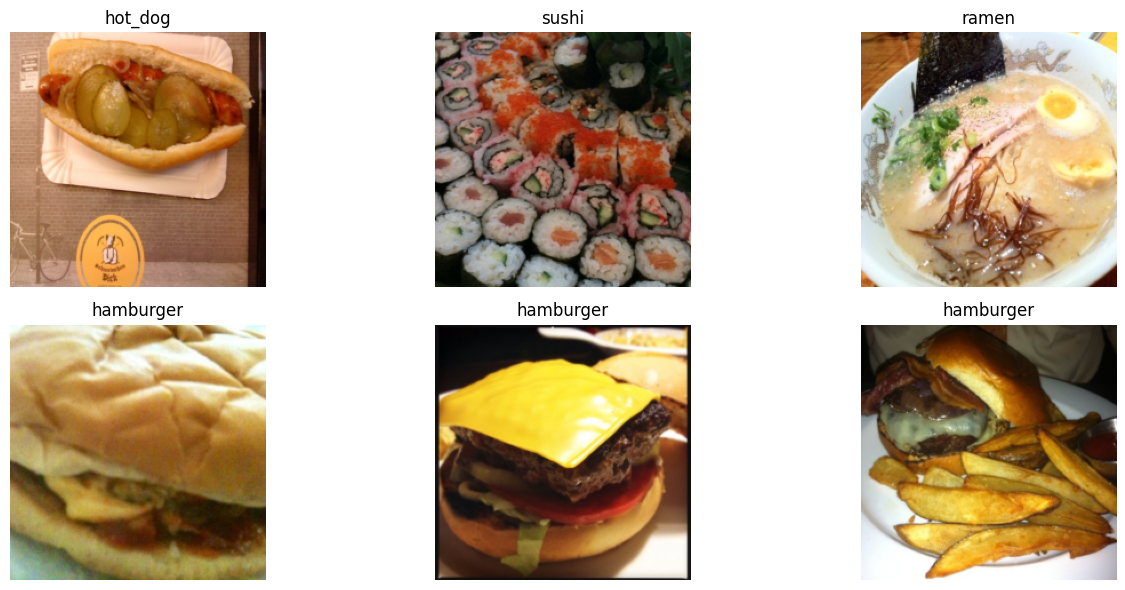

In [9]:
inv_normalize = transforms.Normalize(
    mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
    std=[1 / 0.229, 1 / 0.224, 1 / 0.225],
)

def show_batch(dataset, n=6):
    fig, axes = plt.subplots(2, math.ceil(n / 2), figsize=(14, 6))
    axes = axes.flatten()
    chosen_indices = random.sample(range(len(dataset)), k=n)

    for ax, idx in zip(axes, chosen_indices):
        image, label = dataset[idx]
        image = inv_normalize(image).clamp(0, 1).permute(1, 2, 0).cpu().numpy()
        ax.imshow(image)
        ax.set_title(SELECTED_CLASSES[label])
        ax.axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_batch(train_dataset, n=6)


## 4. 定义 ResNet18 迁移学习模型

这一部分正对应作业核心要求：

- 加载预训练 `ResNet18`
- 冻结 backbone
- 替换最后一层


In [10]:
def load_resnet18_backbone():
    if not USE_PRETRAINED_WEIGHTS:
        print("Using ResNet18 without pretrained weights.")
        return models.resnet18(weights=None)

    try:
        print("Trying torchvision pretrained ResNet18 weights ...")
        return models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    except Exception as exc:
        print("torchvision pretrained download failed:", repr(exc))

    weights_path = DATA_ROOT / "resnet18-f37072fd.pth"
    if not weights_path.exists():
        print("Downloading ResNet18 weights with curl fallback ...")
        download_file_with_curl(RESNET18_WEIGHTS_URL, weights_path)
    else:
        print("Found cached ResNet18 weights:", weights_path)

    model = models.resnet18(weights=None)
    state_dict = torch.load(weights_path, map_location="cpu")
    model.load_state_dict(state_dict)
    print("Loaded pretrained weights from local cache.")
    return model


def build_model(num_classes):
    model = load_resnet18_backbone()

    # 冻结 backbone
    for param in model.parameters():
        param.requires_grad = False

    # 替换最后一层
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, num_classes)
    return model.to(device)


model = build_model(num_classes=len(SELECTED_CLASSES))
model
    


Trying torchvision pretrained ResNet18 weights ...


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [11]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable_params:,}")
print(f"Total params:     {total_params:,}")


Trainable params: 5,130
Total params:     11,181,642


## 5. 训练与验证函数


In [12]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, running_correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    all_probs = []
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            probs = torch.softmax(outputs, dim=1)
            preds = outputs.argmax(dim=1)

            running_loss += loss.item() * images.size(0)
            running_correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_probs.append(probs.cpu())
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    return (
        running_loss / total,
        running_correct / total,
        torch.cat(all_probs),
        torch.cat(all_preds),
        torch.cat(all_labels),
    )


def format_markdown_table(rows):
    headers = ["Experiment", "Backbone", "Frozen Backbone", "LR", "Epochs", "Val Acc"]
    table = [
        "| " + " | ".join(headers) + " |",
        "|---|---|---:|---:|---:|---:|",
    ]
    for row in rows:
        table.append(
            f"| {row['Experiment']} | {row['Backbone']} | {row['Frozen Backbone']} | "
            f"{row['LR']} | {row['Epochs']} | {row['Val Acc']:.4f} |"
        )
    return "\n".join(table)


## 6. 运行两组学习率实验

下面默认比较：

- `lr = 0.001`
- `lr = 0.0001`

这一步就满足“修改一个超参数并进行对比”的要求。


In [13]:
criterion = nn.CrossEntropyLoss()

experiment_histories = {}
result_rows = []
best_model_path = None
best_val_acc = -1.0

for lr in LEARNING_RATES:
    print("=" * 60)
    print(f"Training with learning rate = {lr}")

    model = build_model(num_classes=len(SELECTED_CLASSES))
    optimizer = optim.Adam(model.fc.parameters(), lr=lr)

    history = []

    for epoch in range(NUM_EPOCHS):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )
        val_loss, val_acc, _, _, _ = evaluate(
            model, test_loader, criterion, device
        )

        row = {
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
        }
        history.append(row)

        print(
            f"Epoch [{epoch + 1}/{NUM_EPOCHS}] | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
        )

    experiment_name = f"lr_{lr:.0e}"
    experiment_histories[experiment_name] = history

    final_val_acc = history[-1]["val_acc"]
    result_rows.append(
        {
            "Experiment": experiment_name,
            "Backbone": "ResNet18",
            "Frozen Backbone": "Yes",
            "LR": lr,
            "Epochs": NUM_EPOCHS,
            "Val Acc": final_val_acc,
        }
    )

    model_path = OUTPUT_DIR / f"best_model_{experiment_name}.pth"
    torch.save(model.state_dict(), model_path)

    if final_val_acc > best_val_acc:
        best_val_acc = final_val_acc
        best_model_path = model_path

with open(OUTPUT_DIR / "history.json", "w", encoding="utf-8") as f:
    json.dump(experiment_histories, f, ensure_ascii=False, indent=2)

with open(OUTPUT_DIR / "result_table.md", "w", encoding="utf-8") as f:
    f.write(format_markdown_table(result_rows))

print("\nBest model:", best_model_path)


Training with learning rate = 0.001
Trying torchvision pretrained ResNet18 weights ...
Epoch [1/20] | train_loss=1.6326 train_acc=0.4927 | val_loss=0.9960 val_acc=0.7640
Epoch [2/20] | train_loss=0.9342 train_acc=0.7397 | val_loss=0.7290 val_acc=0.8030
Epoch [3/20] | train_loss=0.7670 train_acc=0.7823 | val_loss=0.6314 val_acc=0.8220
Epoch [4/20] | train_loss=0.6743 train_acc=0.7960 | val_loss=0.5726 val_acc=0.8330
Epoch [5/20] | train_loss=0.5985 train_acc=0.8257 | val_loss=0.5664 val_acc=0.8380
Epoch [6/20] | train_loss=0.5735 train_acc=0.8297 | val_loss=0.5683 val_acc=0.8280
Epoch [7/20] | train_loss=0.5368 train_acc=0.8387 | val_loss=0.5275 val_acc=0.8330
Epoch [8/20] | train_loss=0.5113 train_acc=0.8380 | val_loss=0.5259 val_acc=0.8340
Epoch [9/20] | train_loss=0.4930 train_acc=0.8470 | val_loss=0.5254 val_acc=0.8350
Epoch [10/20] | train_loss=0.4686 train_acc=0.8567 | val_loss=0.5086 val_acc=0.8360
Epoch [11/20] | train_loss=0.4581 train_acc=0.8613 | val_loss=0.5041 val_acc=0.844

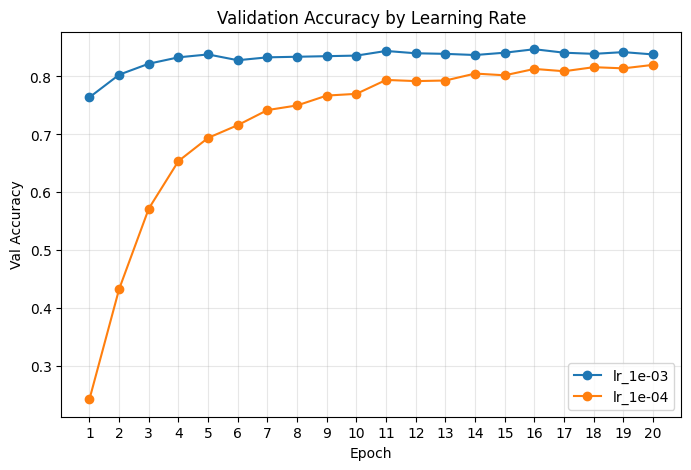

In [14]:
for name, history in experiment_histories.items():
    epochs = [item["epoch"] for item in history]
    val_accs = [item["val_acc"] for item in history]
    plt.plot(epochs, val_accs, marker="o", label=name)

plt.title("Validation Accuracy by Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("Val Accuracy")
plt.xticks(range(1, NUM_EPOCHS + 1))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [15]:
print(format_markdown_table(result_rows))


| Experiment | Backbone | Frozen Backbone | LR | Epochs | Val Acc |
|---|---|---:|---:|---:|---:|
| lr_1e-03 | ResNet18 | Yes | 0.001 | 20 | 0.8380 |
| lr_1e-04 | ResNet18 | Yes | 0.0001 | 20 | 0.8200 |


## 7. 加载最佳模型并做 top-3 推理


In [16]:
best_model = build_model(num_classes=len(SELECTED_CLASSES))
best_model.load_state_dict(torch.load(best_model_path, map_location=device))
best_model.eval()

print("Loaded:", best_model_path)


Trying torchvision pretrained ResNet18 weights ...
Loaded: outputs/best_model_lr_1e-03.pth


In [17]:
def predict_tensor(model, image_tensor, topk=3):
    x = image_tensor.unsqueeze(0).to(device)
    with torch.no_grad():
        outputs = model(x)
        probs = torch.softmax(outputs, dim=1)
        top_probs, top_indices = torch.topk(probs, k=topk, dim=1)

    result = []
    for prob, idx in zip(top_probs[0].cpu().tolist(), top_indices[0].cpu().tolist()):
        result.append((SELECTED_CLASSES[idx], prob))
    return result


def show_prediction(dataset, index, model, topk=3):
    image_tensor, label = dataset[index]
    image = inv_normalize(image_tensor).clamp(0, 1).permute(1, 2, 0).cpu().numpy()
    result = predict_tensor(model, image_tensor, topk=topk)

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.title(f"True label: {SELECTED_CLASSES[label]}")
    plt.axis("off")
    plt.show()

    print("Top-3 predictions:")
    for rank, (class_name, prob) in enumerate(result, start=1):
        print(f"{rank}. {class_name} - {prob * 100:.2f}%")


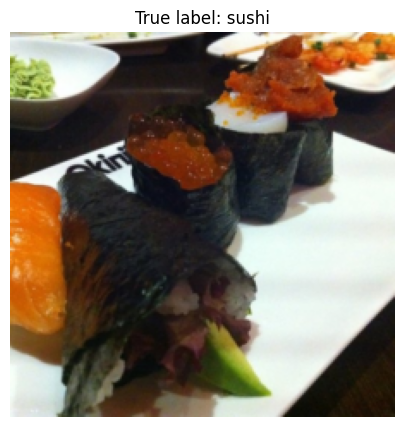

Top-3 predictions:
1. sushi - 93.94%
2. hamburger - 3.33%
3. steak - 1.37%


In [18]:
random_index = random.randint(0, len(test_dataset) - 1)
show_prediction(test_dataset, random_index, best_model, topk=3)


## 8. 自动找出失败案例

这一部分会在测试集里自动找到预测错误的样本，并展示前三个失败案例，方便你截图整理作业材料。


In [19]:
def find_failure_cases(model, dataset, max_cases=3):
    failures = []
    model.eval()

    for idx in range(len(dataset)):
        image_tensor, label = dataset[idx]
        result = predict_tensor(model, image_tensor, topk=3)
        pred_label = SELECTED_CLASSES.index(result[0][0])

        if pred_label != label:
            failures.append(
                {
                    "index": idx,
                    "true_label": SELECTED_CLASSES[label],
                    "predictions": result,
                }
            )
        if len(failures) >= max_cases:
            break
    return failures


failure_cases = find_failure_cases(best_model, test_dataset, max_cases=3)
print("Number of failure cases collected:", len(failure_cases))
failure_cases


Number of failure cases collected: 3


[{'index': 8,
  'true_label': 'ramen',
  'predictions': [('steak', 0.3336617946624756),
   ('sushi', 0.3091939687728882),
   ('fried_rice', 0.15560688078403473)]},
 {'index': 13,
  'true_label': 'ramen',
  'predictions': [('ice_cream', 0.6216822862625122),
   ('donuts', 0.21880657970905304),
   ('ramen', 0.10678903758525848)]},
 {'index': 29,
  'true_label': 'ramen',
  'predictions': [('fried_rice', 0.6874197721481323),
   ('ramen', 0.24072471261024475),
   ('steak', 0.04400984197854996)]}]

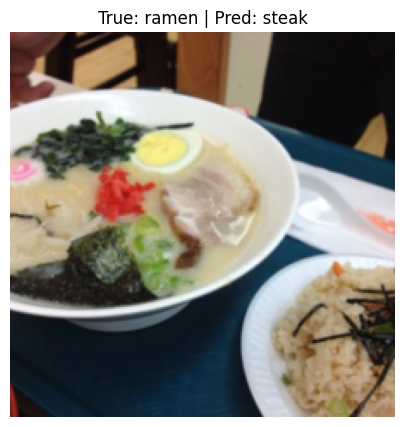

Sample index: 8
True label: ramen
Top-3 predictions:
1. steak - 33.37%
2. sushi - 30.92%
3. fried_rice - 15.56%
------------------------------------------------------------


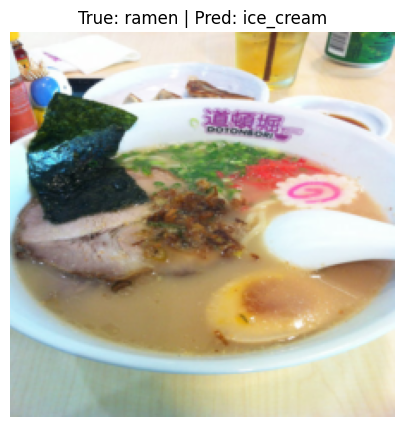

Sample index: 13
True label: ramen
Top-3 predictions:
1. ice_cream - 62.17%
2. donuts - 21.88%
3. ramen - 10.68%
------------------------------------------------------------


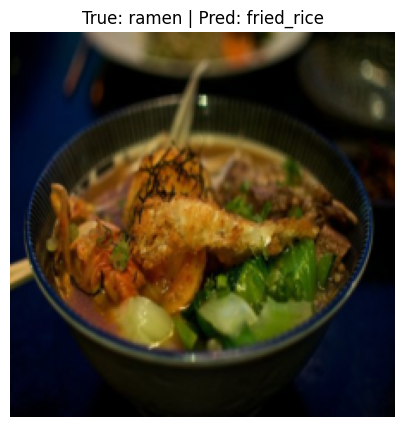

Sample index: 29
True label: ramen
Top-3 predictions:
1. fried_rice - 68.74%
2. ramen - 24.07%
3. steak - 4.40%
------------------------------------------------------------


In [20]:
for item in failure_cases:
    idx = item["index"]
    image_tensor, _ = test_dataset[idx]
    image = inv_normalize(image_tensor).clamp(0, 1).permute(1, 2, 0).cpu().numpy()

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.title(
        f"True: {item['true_label']} | Pred: {item['predictions'][0][0]}"
    )
    plt.axis("off")
    plt.show()

    print(f"Sample index: {idx}")
    print(f"True label: {item['true_label']}")
    print("Top-3 predictions:")
    for rank, (class_name, prob) in enumerate(item["predictions"], start=1):
        print(f"{rank}. {class_name} - {prob * 100:.2f}%")
    print("-" * 60)


## 9. 失败案例说明



1. 案例 1：`真实类别` 被预测成 `预测类别`
   原因可写：颜色、纹理、摆盘方式接近，模型容易混淆。
2. 案例 2：`真实类别` 被预测成 `预测类别`
   原因可写：食物外形相似，top-1 容易出错，但 top-3 仍包含正确类别。
3. 案例 3：`真实类别` 被预测成 `预测类别`
   原因可写：图像背景复杂、食物占比低，影响识别稳定性。


## 10. 小组项目连接点



> 用 Food-101 数据集和 ResNet18 完成了食物分类任务，训练过程中实现了 backbone 冻结、最后一层替换以及超参数调整。后续小组项目将把分类结果进一步映射到热量数据库，实现“AI 热量识别助手”，用于健康饮食管理。


## 11. 后续

- 训练过程输出
- 两组 learning rate 的结果表
- 任意一张 top-3 预测结果
- 三个失败案例
